In [53]:

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


phase           model            
claude_archive  claude-3.5-sonnet    15
llm_core        llama-70b            73
                qwen-235b            27


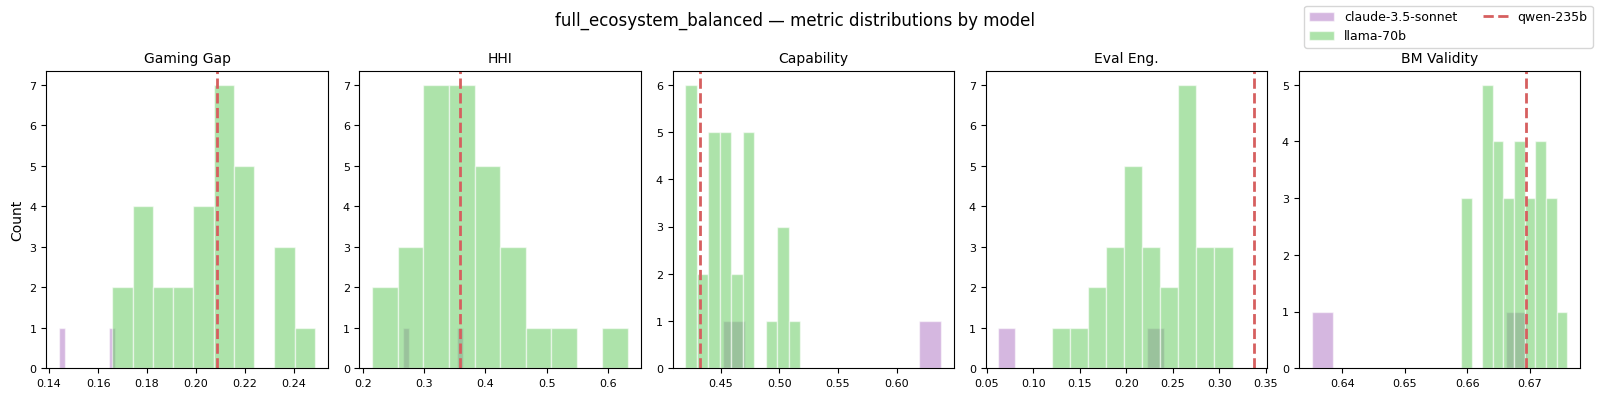

In [54]:
ROOT = Path("..").resolve()
runs_path = ROOT / "hf_data" / "runs.jsonl"

rows = [json.loads(l) for l in runs_path.read_text().splitlines() if l.strip()]
df = pd.DataFrame(rows)

df = df[df['model'] != 'heuristic']  # Exclude heuristic for now to focus on LLMs

PRESETS = ["balanced", "us", "eu"]

def split_condition(c):
    for p in PRESETS:
        if c.endswith("_" + p):
            return c[:-(len(p) + 1)], p
    return c, "balanced"

df[["condition_base", "preset"]] = pd.DataFrame(
    df["condition"].apply(split_condition).tolist(), index=df.index
)

CONDITION_LABELS = {
    "full_ecosystem":              "Full Ecosystem",
    "ablation_no_media":           "No Media",
    "ablation_no_incidents":       "No Incidents",
    "ablation_no_startups":        "No Startups",
    "ablation_no_opencore":        "No OpenCore",
    "ablation_single_benchmark":   "Single Benchmark",
    "ablation_no_funders":         "No Funders",
    "ablation_no_bench_evolution": "No Bench Evolution",
    "ablation_eval_as_company":    "Eval As Company",
}
COND_ORDER = list(CONDITION_LABELS.keys())

df["condition_label"] = df["condition_base"].map(CONDITION_LABELS).fillna(df["condition_base"])

METRICS = ["gaming_gap_final", "hhi_final", "mean_capability_final",
           "mean_eval_eng_final", "benchmark_validity_final"]
METRIC_LABELS = {
    "gaming_gap_final":        "Gaming Gap",
    "hhi_final":               "HHI",
    "mean_capability_final":   "Capability",
    "mean_eval_eng_final":     "Eval Eng.",
    "benchmark_validity_final":"BM Validity",
}

PATTERNS = [
    "pattern_score_inflation", "pattern_benchmark_turnover",
    "pattern_regulatory_escalation", "pattern_commoditization_shock",
    "pattern_safety_incident_response", "pattern_gaming_persistence",
    "pattern_funding_follows_scores",
]
PATTERN_LABELS = [
    "Score Infl.", "Bench Turn.", "Reg. Escal.", "Commoditiz.",
    "Safety Resp.", "Gaming Pers.", "Funding→Scores",
]

MODEL_COLORS = {
    "heuristic":          "#4878CF",
    "llama-70b":          "#6ACC65",
    "qwen-235b":          "#D65F5F",
    "claude-3.5-sonnet":  "#B47CC7",
}
PRESET_COLORS = {"balanced": "#4878CF", "us": "#6ACC65", "eu": "#D65F5F"}

print(df.groupby(["phase", "model"]).size().to_string())


# ── 1. Cross-model metric distributions (full_ecosystem_balanced) ─────────────

fe = df[df["condition"] == "full_ecosystem_balanced"].copy()

fig, axes = plt.subplots(1, len(METRICS), figsize=(16, 4))
for ax, metric in zip(axes, METRICS):
    for model, grp in fe.groupby("model"):
        vals = grp[metric].dropna()
        color = MODEL_COLORS.get(model, "gray")
        if len(vals) == 1:
            ax.axvline(vals.iloc[0], label=model, color=color, linewidth=2, linestyle="--")
        elif len(vals) > 1:
            ax.hist(vals, bins=10, alpha=0.55, label=model, color=color, edgecolor="white")
    ax.set_title(METRIC_LABELS[metric], fontsize=10)
    ax.tick_params(labelsize=8)

axes[0].set_ylabel("Count")
handles, labels = axes[-1].get_legend_handles_labels()
seen = {}
[seen.update({l: h}) for h, l in zip(handles, labels)]
fig.legend(seen.values(), seen.keys(), loc="upper right", fontsize=9, ncol=2)
fig.suptitle("full_ecosystem_balanced — metric distributions by model", fontsize=12)
plt.tight_layout()
plt.show()

In [55]:
rows_out = []
for model in fe["model"].unique():
    grp = fe[fe["model"] == model]
    row = {"model": model, "N": len(grp)}
    for m in METRICS:
        vals = grp[m].dropna()
        mu, sd = vals.mean(), vals.std()
        row[METRIC_LABELS[m]] = f"{mu:.3f}" + (f" ±{sd:.3f}" if len(vals) > 1 else "")
    rows_out.append(row)

print(pd.DataFrame(rows_out).set_index("model").to_string())

                    N    Gaming Gap           HHI    Capability     Eval Eng.   BM Validity
model                                                                                      
llama-70b          30  0.205 ±0.021  0.368 ±0.084  0.457 ±0.027  0.233 ±0.050  0.667 ±0.004
qwen-235b           1         0.209         0.359         0.432         0.338         0.669
claude-3.5-sonnet   2  0.155 ±0.016  0.314 ±0.070  0.545 ±0.131  0.151 ±0.126  0.652 ±0.024


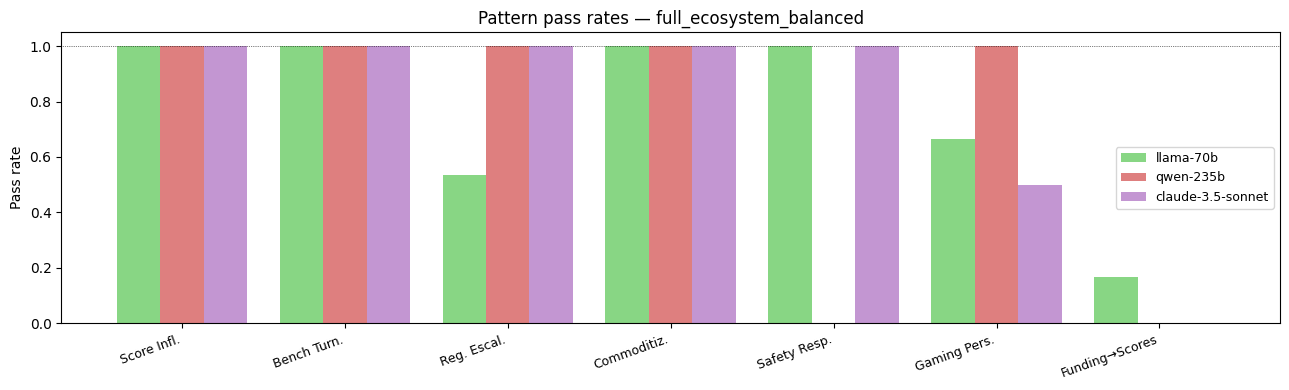

In [56]:
# Pattern pass rates by model (full_ecosystem_balanced)
models_order = ["llama-70b", "qwen-235b", "claude-3.5-sonnet"]
models_present = [m for m in models_order if m in fe["model"].values]

rate_data = {}
for model in models_present:
    grp = fe[fe["model"] == model]
    rate_data[model] = [grp[p].mean() if p in grp.columns else np.nan for p in PATTERNS]

x = np.arange(len(PATTERNS))
width = 0.8 / len(models_present)

fig, ax = plt.subplots(figsize=(13, 4))
for i, model in enumerate(models_present):
    offset = (i - len(models_present) / 2 + 0.5) * width
    ax.bar(x + offset, rate_data[model], width, label=model,
           color=MODEL_COLORS.get(model, "gray"), alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(PATTERN_LABELS, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Pass rate")
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color="black", linewidth=0.5, linestyle=":")
ax.legend(fontsize=9)
ax.set_title("Pattern pass rates — full_ecosystem_balanced", fontsize=12)
plt.tight_layout()
plt.show()


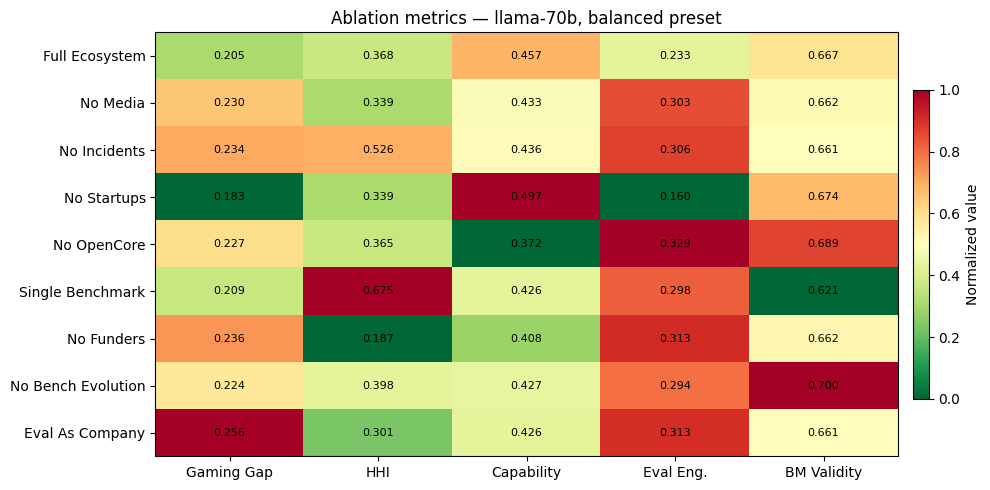


Ablation deltas vs Full Ecosystem (llama-70b, balanced):
                    Gaming Gap    HHI  Capability  Eval Eng.  BM Validity
No Media                +0.025 -0.029      -0.025     +0.071       -0.005
No Incidents            +0.029 +0.158      -0.022     +0.074       -0.007
No Startups             -0.023 -0.029      +0.039     -0.073       +0.007
No OpenCore             +0.021 -0.003      -0.085     +0.096       +0.022
Single Benchmark        +0.004 +0.308      -0.031     +0.066       -0.046
No Funders              +0.031 -0.180      -0.050     +0.080       -0.005
No Bench Evolution      +0.019 +0.030      -0.030     +0.061       +0.033
Eval As Company         +0.050 -0.067      -0.031     +0.080       -0.006


In [57]:
# Ablation heatmap — llama-70b, balanced preset
llm_bal = df[(df["phase"] == "llm_core") & (df["model"] == "llama-70b") & (df["preset"] == "balanced")]

abl_means = (
    llm_bal.groupby("condition_base")[METRICS].mean()
    .reindex(COND_ORDER)
)
abl_means.index = [CONDITION_LABELS.get(c, c) for c in abl_means.index]
normed = (abl_means - abl_means.min()) / (abl_means.max() - abl_means.min() + 1e-9)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(normed.values, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(METRICS)))
ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS], fontsize=10)
ax.set_yticks(range(len(abl_means)))
ax.set_yticklabels(abl_means.index, fontsize=10)
for i in range(len(abl_means)):
    for j in range(len(METRICS)):
        v = abl_means.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8)
ax.set_title("Ablation metrics — llama-70b, balanced preset", fontsize=12)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label="Normalized value")
plt.tight_layout()
plt.show()

# Delta table vs full_ecosystem
baseline = abl_means.loc["Full Ecosystem"]
deltas = abl_means.drop("Full Ecosystem") - baseline
deltas.columns = [METRIC_LABELS[m] for m in METRICS]
print("\nAblation deltas vs Full Ecosystem (llama-70b, balanced):")
print(deltas.to_string(float_format=lambda x: f"{x:+.3f}"))


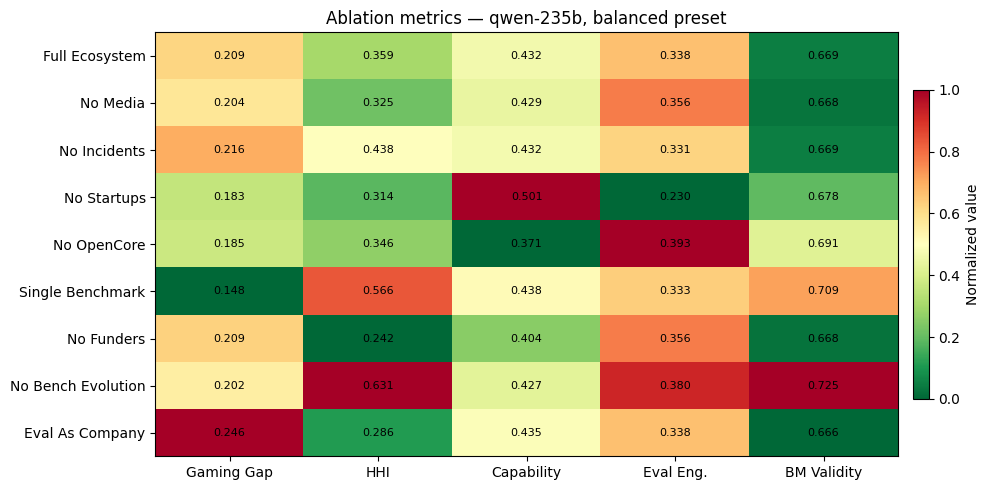


Ablation deltas vs Full Ecosystem (qwen-235b, balanced):
                    Gaming Gap    HHI  Capability  Eval Eng.  BM Validity
No Media                -0.004 -0.034      -0.003     +0.019       -0.001
No Incidents            +0.007 +0.079      +0.001     -0.006       +0.000
No Startups             -0.026 -0.045      +0.070     -0.108       +0.009
No OpenCore             -0.024 -0.013      -0.061     +0.055       +0.022
Single Benchmark        -0.061 +0.207      +0.006     -0.004       +0.039
No Funders              +0.001 -0.117      -0.028     +0.019       -0.001
No Bench Evolution      -0.007 +0.272      -0.005     +0.042       +0.056
Eval As Company         +0.037 -0.073      +0.003     +0.000       -0.003


In [66]:
# Ablation heatmap — llama-70b, balanced preset
llm_bal = df[(df["phase"] == "llm_core") & (df["model"] == "qwen-235b") & (df["preset"] == "balanced")]

abl_means = (
    llm_bal.groupby("condition_base")[METRICS].mean()
    .reindex(COND_ORDER)
)
abl_means.index = [CONDITION_LABELS.get(c, c) for c in abl_means.index]
normed = (abl_means - abl_means.min()) / (abl_means.max() - abl_means.min() + 1e-9)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(normed.values, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(METRICS)))
ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS], fontsize=10)
ax.set_yticks(range(len(abl_means)))
ax.set_yticklabels(abl_means.index, fontsize=10)
for i in range(len(abl_means)):
    for j in range(len(METRICS)):
        v = abl_means.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8)
ax.set_title("Ablation metrics — qwen-235b, balanced preset", fontsize=12)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label="Normalized value")
plt.tight_layout()
plt.show()

# Delta table vs full_ecosystem
baseline = abl_means.loc["Full Ecosystem"]
deltas = abl_means.drop("Full Ecosystem") - baseline
deltas.columns = [METRIC_LABELS[m] for m in METRICS]
print("\nAblation deltas vs Full Ecosystem (qwen-235b, balanced):")
print(deltas.to_string(float_format=lambda x: f"{x:+.3f}"))


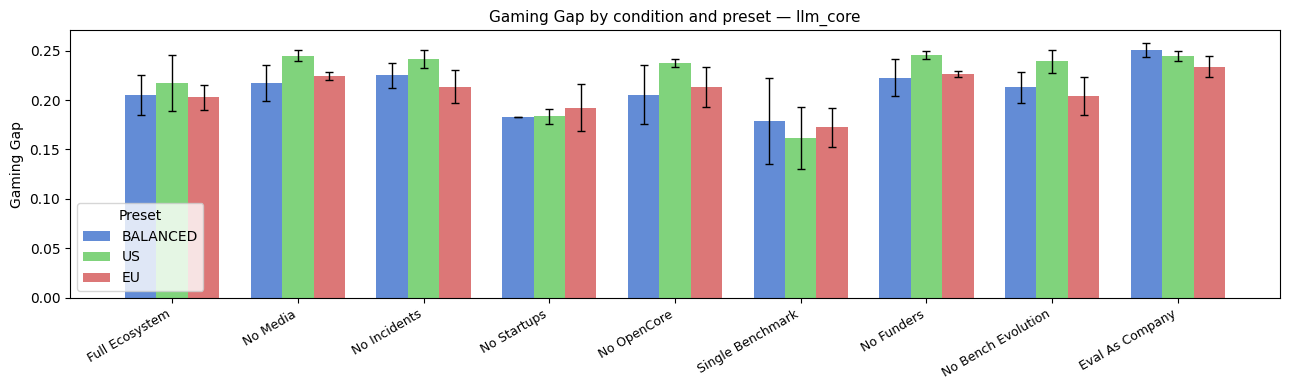

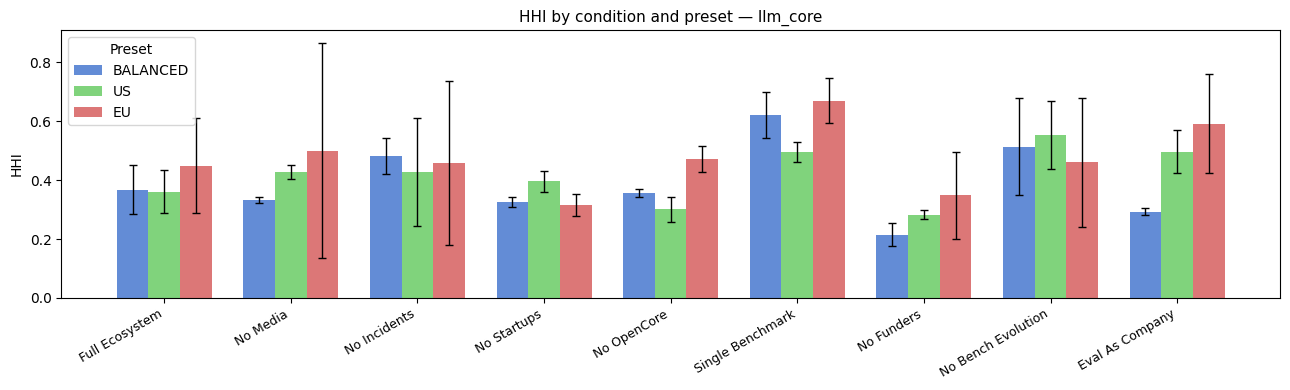

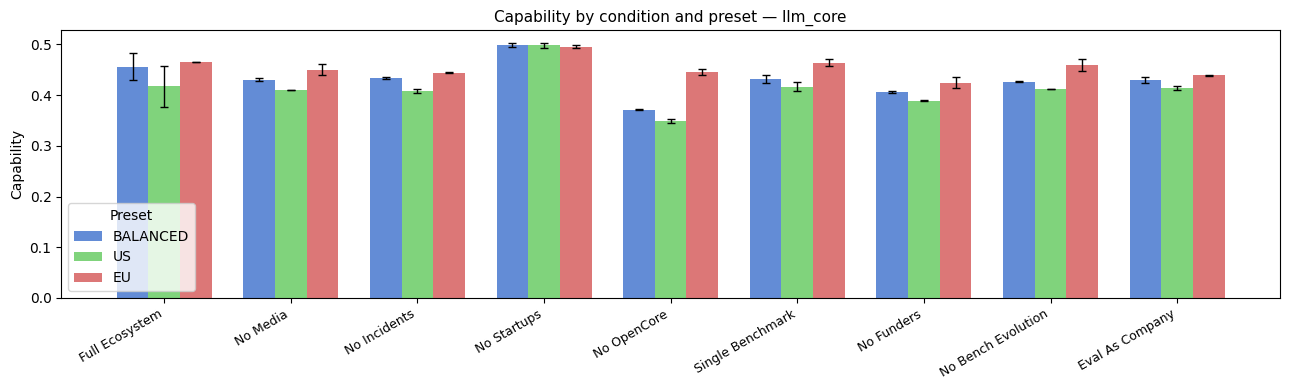

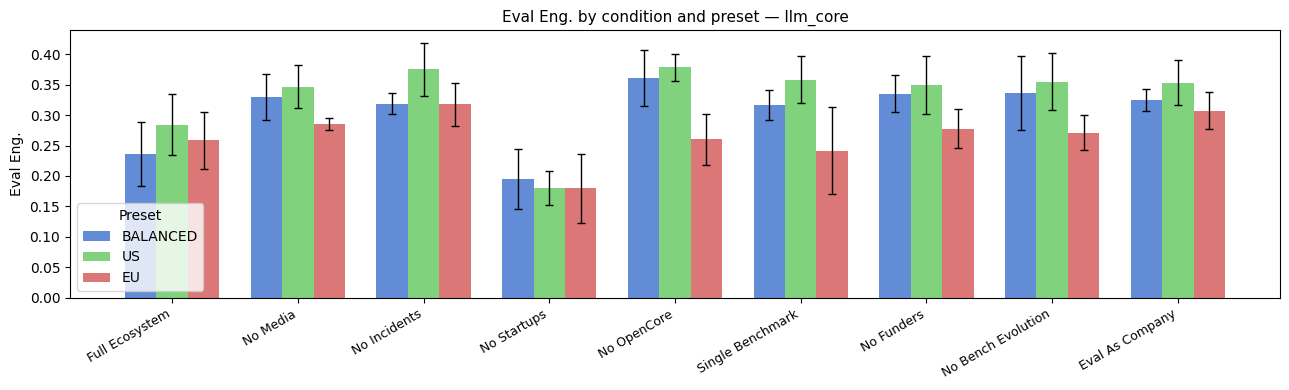

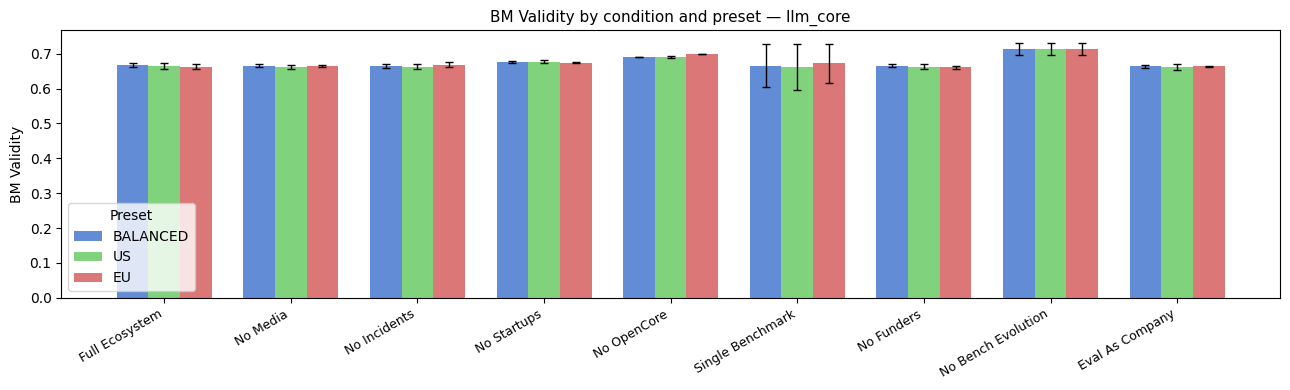

In [58]:
# Preset comparison — llama-70b, grouped bars per metric
llm_all = df[df["phase"] == "llm_core"]

for metric in METRICS:
    preset_means = (
        llm_all.groupby(["condition_base", "preset"])[metric].mean()
        .unstack("preset").reindex(COND_ORDER)
    )
    preset_stds = (
        llm_all.groupby(["condition_base", "preset"])[metric].std()
        .unstack("preset").reindex(COND_ORDER)
    )
    labels = [CONDITION_LABELS.get(c, c) for c in preset_means.index]
    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(13, 4))
    for i, preset in enumerate(PRESETS):
        if preset not in preset_means.columns:
            continue
        offset = (i - 1) * width
        ax.bar(x + offset, preset_means[preset], width, yerr=preset_stds[preset],
               label=preset.upper(), color=PRESET_COLORS[preset], alpha=0.85,
               capsize=3, error_kw={"linewidth": 1})
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.legend(title="Preset")
    ax.set_title(f"{METRIC_LABELS[metric]} by condition and preset — llm_core", fontsize=11)
    plt.tight_layout()
    plt.show()


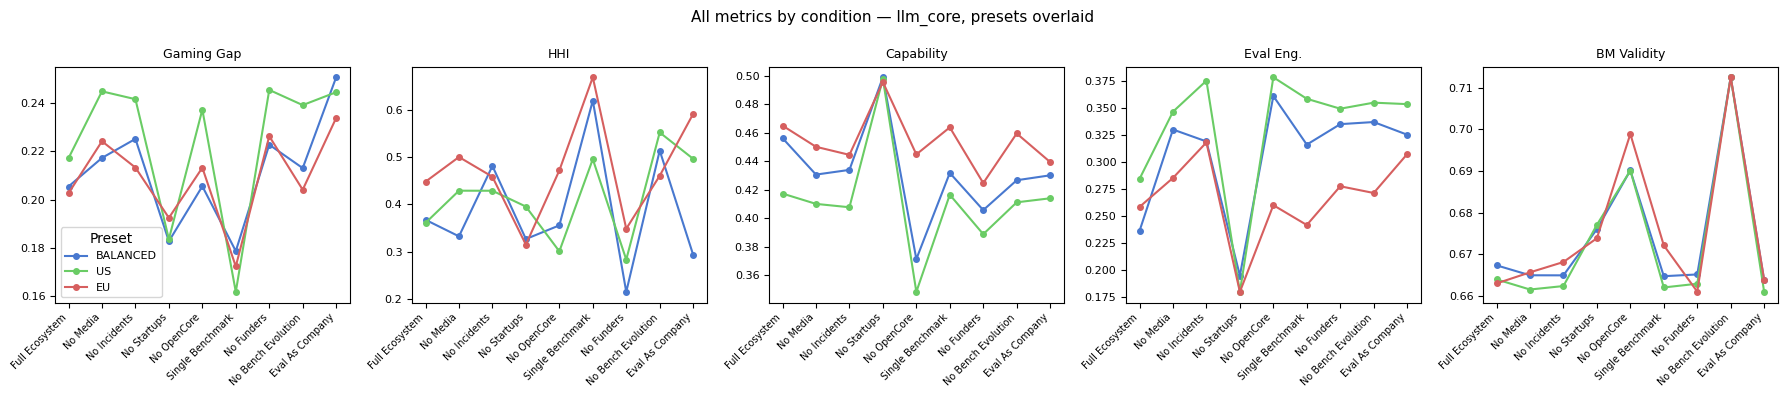

In [59]:
# All metrics x preset — line overlay (llm_core)
llm_all = df[df["phase"] == "llm_core"]

fig, axes = plt.subplots(1, len(METRICS), figsize=(18, 4))
for ax, metric in zip(axes, METRICS):
    for preset in PRESETS:
        grp = llm_all[llm_all["preset"] == preset]
        means = grp.groupby("condition_base")[metric].mean().reindex(COND_ORDER)
        ax.plot(range(len(COND_ORDER)), means.values, marker="o", markersize=4,
                label=preset.upper(), color=PRESET_COLORS[preset], linewidth=1.5)
    ax.set_title(METRIC_LABELS[metric], fontsize=9)
    ax.set_xticks(range(len(COND_ORDER)))
    ax.set_xticklabels([CONDITION_LABELS.get(c, c) for c in COND_ORDER],
                       rotation=45, ha="right", fontsize=7)
    ax.tick_params(axis="y", labelsize=8)

axes[0].legend(title="Preset", fontsize=8)
fig.suptitle("All metrics by condition — llm_core, presets overlaid", fontsize=11)
plt.tight_layout()
plt.show()


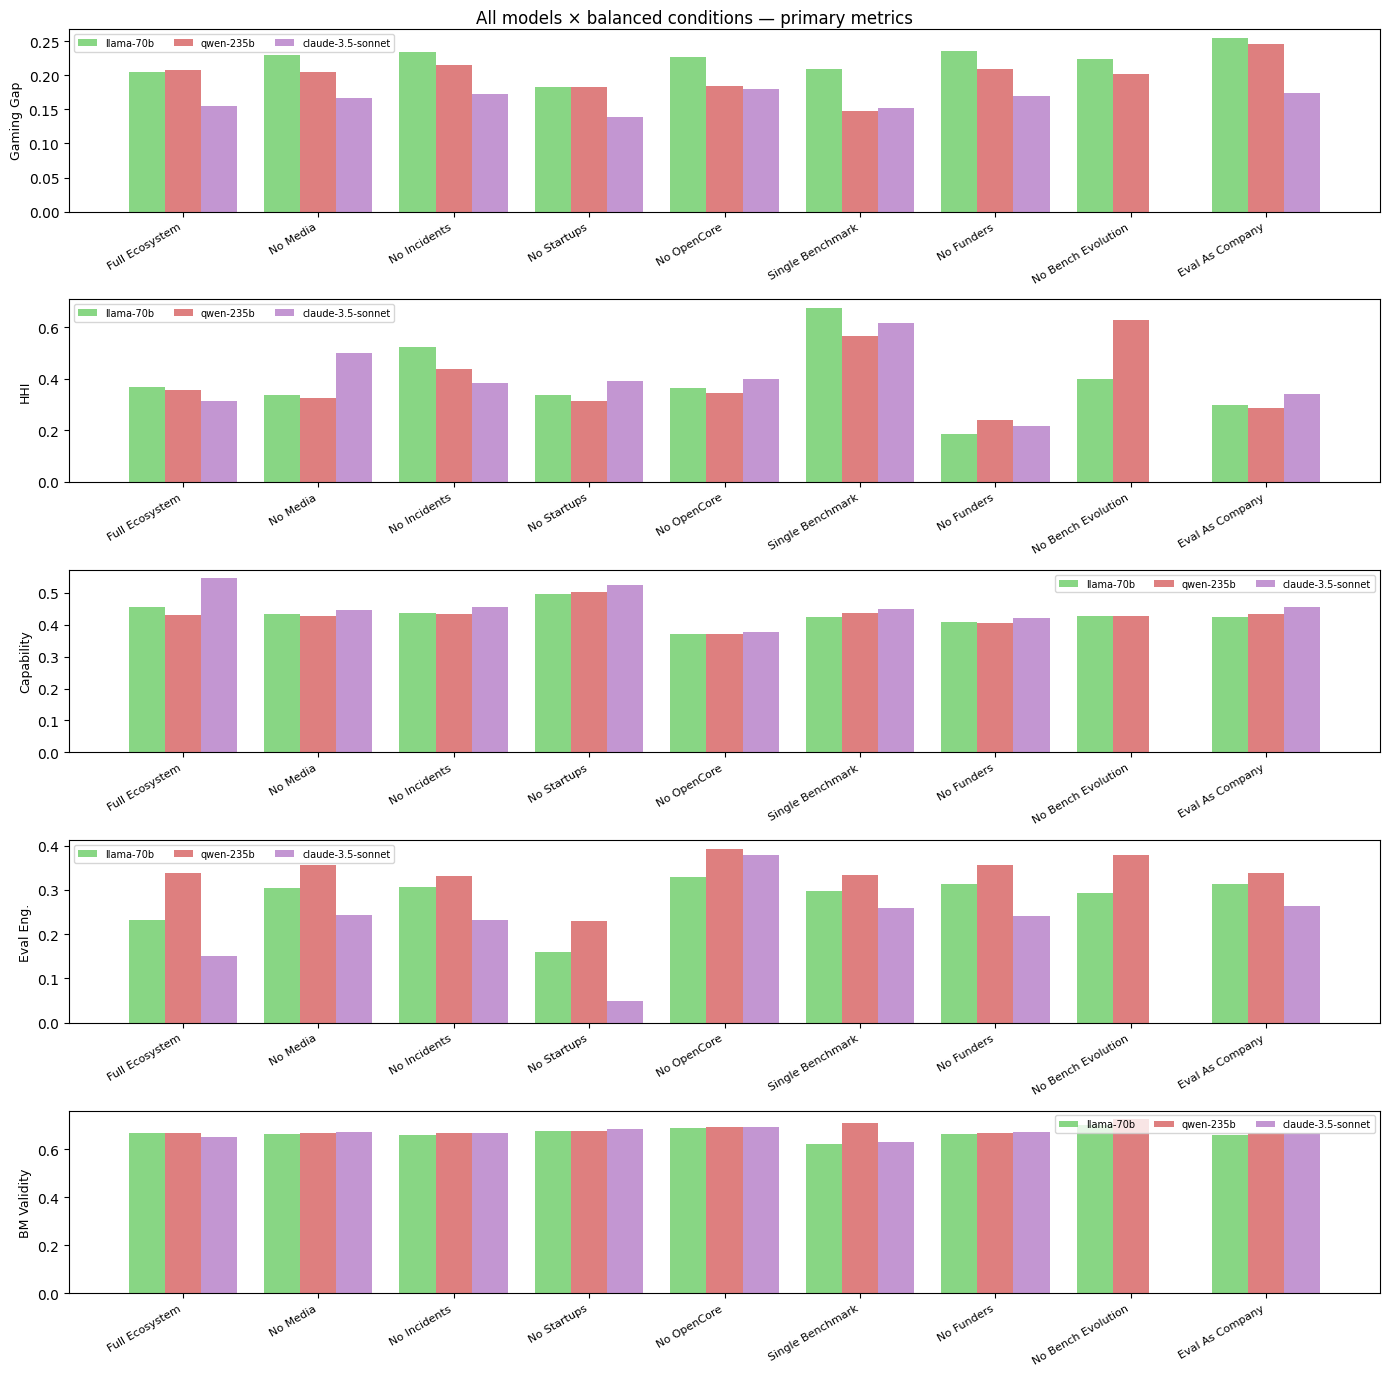

In [60]:
all_models = ["llama-70b", "qwen-235b", "claude-3.5-sonnet"]
all_conds_balanced = [c + "_balanced" for c in COND_ORDER]

model_condition_means = {
    (model, cond): grp[METRICS].mean()
    for (model, cond), grp in df.groupby(["model", "condition"])
}

fig, axes = plt.subplots(len(METRICS), 1, figsize=(14, 14))
x = np.arange(len(all_conds_balanced))
width = 0.8 / len(all_models)

for ax, metric in zip(axes, METRICS):
    for i, model in enumerate(all_models):
        vals = [
            model_condition_means.get((model, c), pd.Series({metric: np.nan}))[metric]
            for c in all_conds_balanced
        ]
        offset = (i - len(all_models) / 2 + 0.5) * width
        ax.bar(x + offset, vals, width, label=model,
               color=MODEL_COLORS.get(model, "gray"), alpha=0.8)
    ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [CONDITION_LABELS.get(c.replace("_balanced", ""), c) for c in all_conds_balanced],
        rotation=30, ha="right", fontsize=8,
    )
    ax.legend(fontsize=7, ncol=4)

fig.suptitle("All models × balanced conditions — primary metrics", fontsize=12)
plt.tight_layout()
plt.show()

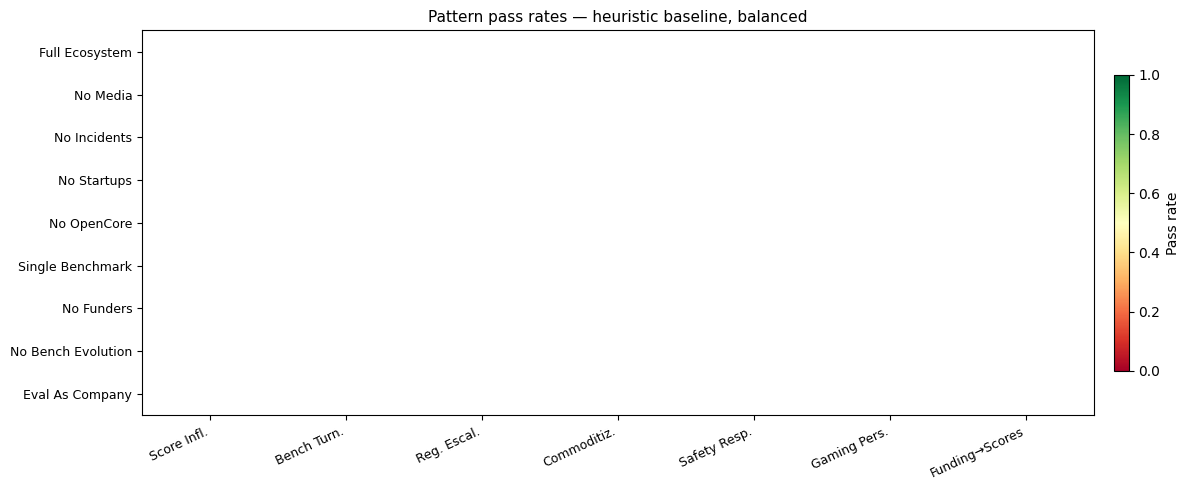

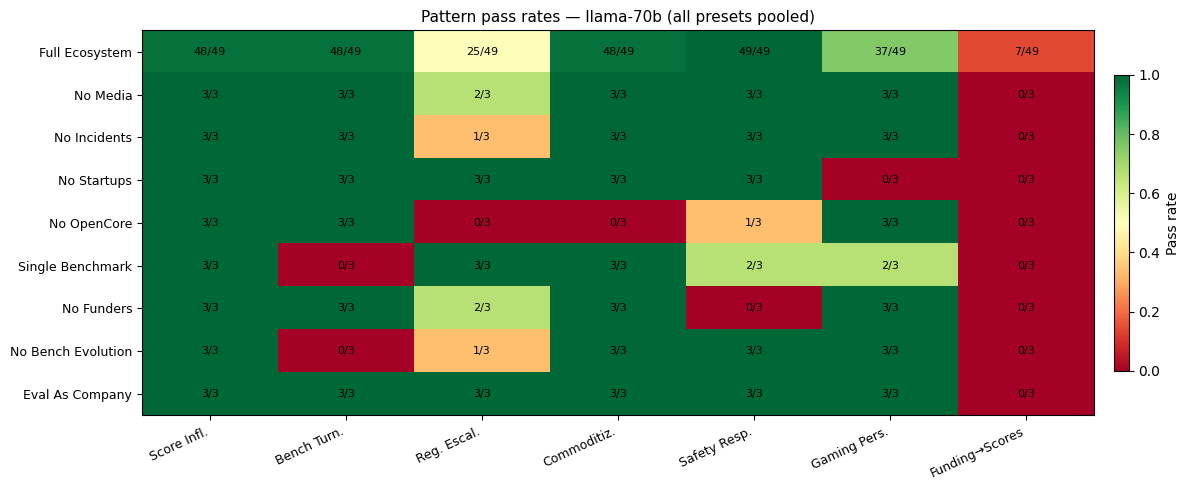

In [61]:
def pattern_heatmap(subset_df, title):
    mat = np.full((len(COND_ORDER), len(PATTERNS)), np.nan)
    counts = np.zeros((len(COND_ORDER), len(PATTERNS)), dtype=int)
    for i, cbase in enumerate(COND_ORDER):
        grp = subset_df[subset_df["condition_base"] == cbase]
        for j, pat in enumerate(PATTERNS):
            if len(grp) > 0 and pat in grp.columns:
                mat[i, j] = grp[pat].mean()
                counts[i, j] = len(grp)

    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(mat, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(PATTERNS)))
    ax.set_xticklabels(PATTERN_LABELS, rotation=25, ha="right", fontsize=9)
    ax.set_yticks(range(len(COND_ORDER)))
    ax.set_yticklabels([CONDITION_LABELS.get(c, c) for c in COND_ORDER], fontsize=9)
    for i in range(len(COND_ORDER)):
        for j in range(len(PATTERNS)):
            if not np.isnan(mat[i, j]):
                k = round(mat[i, j] * counts[i, j])
                ax.text(j, i, f"{k}/{counts[i,j]}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.015, pad=0.02, label="Pass rate")
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()


pattern_heatmap(
    df[(df["phase"] == "heuristic_baseline") & (df["preset"] == "balanced")],
    "Pattern pass rates — heuristic baseline, balanced",
)
pattern_heatmap(
    df[(df["phase"] == "llm_core") & (df["model"] == "llama-70b")],
    "Pattern pass rates — llama-70b (all presets pooled)",
)

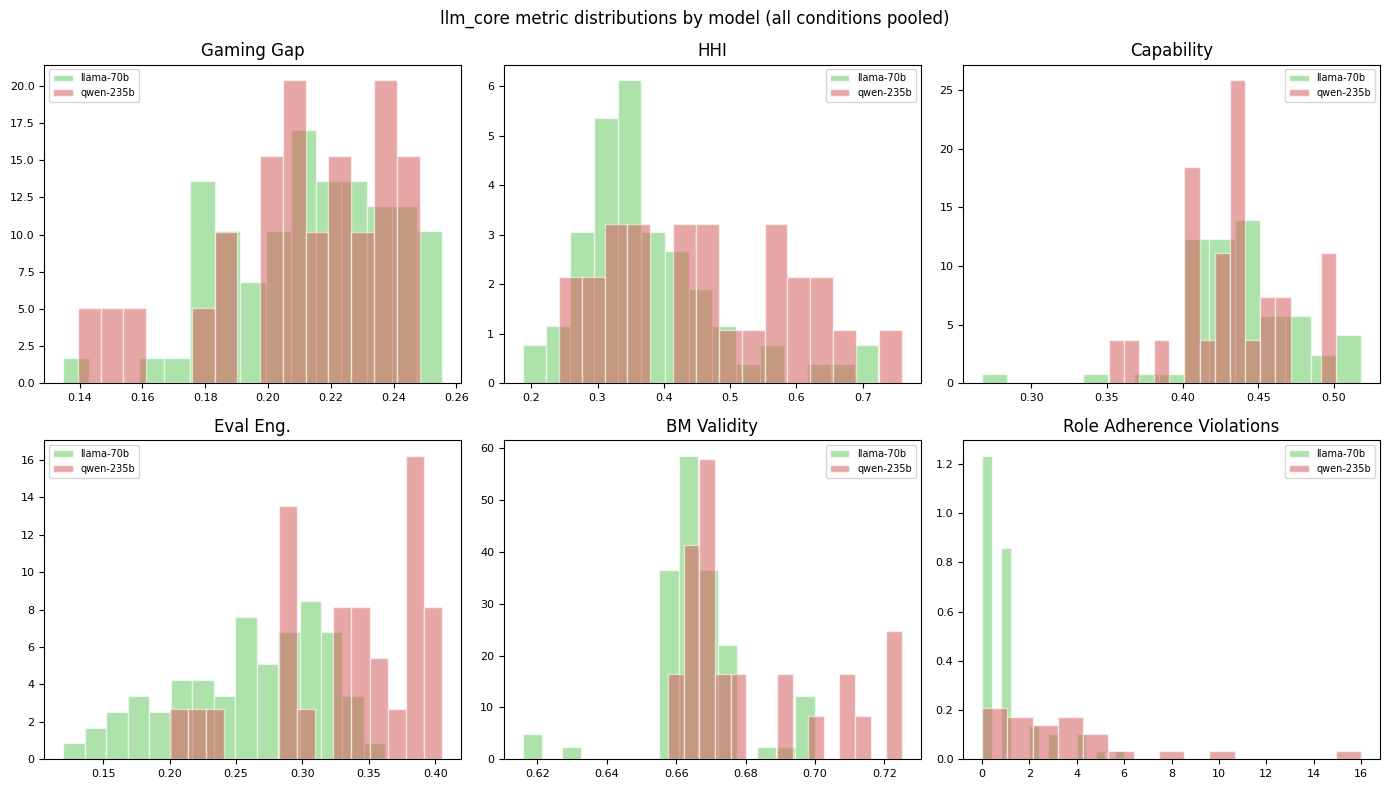

In [68]:
# llm_core metric distributions by model (all conditions pooled)
llm_all = df[df["phase"] == "llm_core"]
all_plot_metrics = METRICS + ["role_adherence_violations"]
all_plot_labels = [METRIC_LABELS.get(m, m) for m in METRICS] + ["Role Adherence Violations"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, metric, label in zip(axes.flatten(), all_plot_metrics, all_plot_labels):
    for model in ["llama-70b", "qwen-235b", "claude-3.5-sonnet"]:
        vals = llm_all[llm_all["model"] == model][metric].dropna()
        if len(vals) == 0:
            continue
        color = MODEL_COLORS.get(model, "gray")
        if len(vals) == 1:
            ax.axvline(vals.iloc[0], label=model, color=color, linewidth=2, linestyle="--")
        else:
            ax.hist(vals, bins=15, alpha=0.55, label=model, color=color, edgecolor="white", density=True)
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

fig.suptitle("llm_core metric distributions by model (all conditions pooled)", fontsize=12)
plt.tight_layout()
plt.show()



llama-70b full_ecosystem_balanced: N=30 seeds


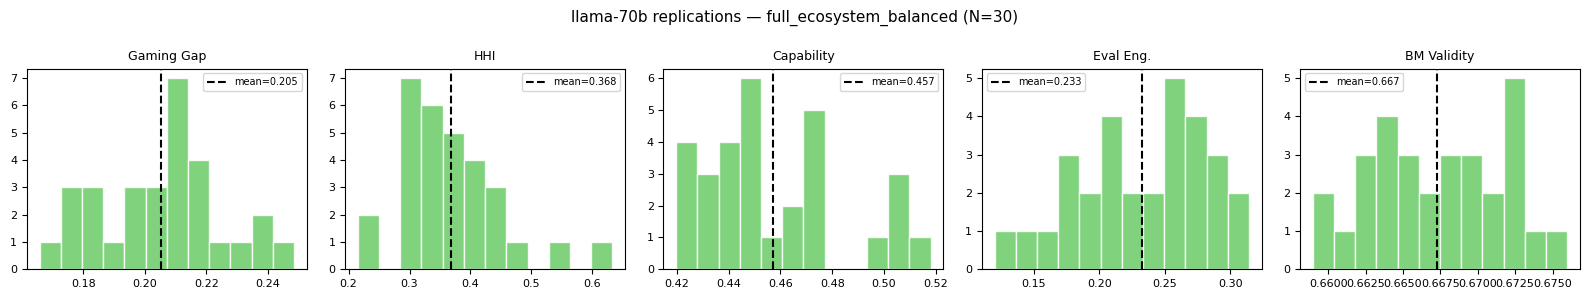


Pattern pass rates (llama-70b, full_ecosystem_balanced):
  Score Infl.              : 30/30 (100%)
  Bench Turn.              : 30/30 (100%)
  Reg. Escal.              : 16/30 (53%)
  Commoditiz.              : 30/30 (100%)
  Safety Resp.             : 30/30 (100%)
  Gaming Pers.             : 20/30 (67%)
  Funding→Scores           : 5/30 (17%)


In [63]:
llama_fe = df[
    (df["phase"] == "llm_core") &
    (df["model"] == "llama-70b") &
    (df["condition"] == "full_ecosystem_balanced")
]
print(f"\nllama-70b full_ecosystem_balanced: N={len(llama_fe)} seeds")

fig, axes = plt.subplots(1, len(METRICS), figsize=(16, 3))
for ax, metric in zip(axes, METRICS):
    vals = llama_fe[metric].dropna()
    ax.hist(vals, bins=12, color=MODEL_COLORS["llama-70b"], edgecolor="white", alpha=0.85)
    ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"mean={vals.mean():.3f}")
    ax.set_title(METRIC_LABELS[metric], fontsize=9)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

fig.suptitle("llama-70b replications — full_ecosystem_balanced (N=30)", fontsize=11)
plt.tight_layout()
plt.show()

print("\nPattern pass rates (llama-70b, full_ecosystem_balanced):")
for p, pl in zip(PATTERNS, PATTERN_LABELS):
    rate = llama_fe[p].mean()
    k = round(rate * len(llama_fe))
    print(f"  {pl:25s}: {k}/{len(llama_fe)} ({rate:.0%})")
